In [17]:
from NeuralNetwork import NeuralNetwork
from Scheduler import *
from functions import *

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

In [18]:
def runge_func(x):
    return 1 / (1 + 25*x**2)

In [28]:
np.random.seed(2025)

degree = 1

xs = np.random.randn(1000)[:,np.newaxis]

X = PolynomialFeatures(degree, include_bias=False).fit_transform(xs)

ys = runge_func(xs)

X_train, X_test, y_train, y_test = train_test_split(X, ys, train_size=0.8)

scalerx = StandardScaler()
scalerx.fit(X_train)
X_train = scalerx.transform(X_train)
X_test  = scalerx.transform(X_test)

scalery = StandardScaler()
scalery.fit(y_train)
y_train = scalery.transform(y_train)
y_test = scalery.transform(y_test)
y_mean = scalery.mean_
print(y_mean)

[0.22506289]


In [29]:
scheduler = Adam(0.001)
ffnn = NeuralNetwork(degree,1, [100,100], [sigmoid, sigmoid, id_func], 
                    [sigmoid_der, sigmoid_der, id_func_der], scheduler, mse, mse_der,
                     regularization = "L2", reg_param=2e-13
                    )

In [30]:
train_pred = ffnn.predict(X_train)
test_pred = ffnn.predict(X_test)
print("BEFORE TRAIN")
old_train = mse(train_pred, y_train)
old_test = mse(test_pred, y_test)
print("train", old_train)
print("test ", old_test)

ffnn.train(X_train, y_train, 20, 100)

train_pred = ffnn.predict(X_train)
test_pred = ffnn.predict(X_test)
print("AFTER TRAIN")
new_train = mse(train_pred, y_train)
new_test = mse(test_pred, y_test)
print("train", new_train)
print("test ", new_test)
print("DIFF")
print("train", new_train-old_train)
print("test", new_test-old_test)

BEFORE TRAIN
train 34.02091253292356
test  32.93527219157486
AFTER TRAIN
train 0.16565120266214295
test  0.1793685546218374
DIFF
train -33.85526133026142
test -32.75590363695302


In [31]:
print(ffnn._weights_biases)
train_pred = ffnn.predict(X_train)
test_pred = ffnn.predict(X_test)

[(array([[-0.14510714,  0.33250462, -1.6534781 ,  1.08711512,  0.55504605,
        -0.26762185, -1.75355882, -0.64970889, -0.49804028, -0.1384774 ,
        -0.33927866, -3.11830003,  1.77939376, -0.8426398 ,  0.07934519,
        -0.57111134, -0.38392529,  1.1088594 , -1.47043754, -0.72249375,
         0.58728279, -2.13365629, -0.23513379, -0.22420421,  0.4688588 ,
         1.20884315, -0.86558525,  0.63851995,  0.73668773, -1.61317984,
         0.20101159, -0.767003  ,  1.35385851, -0.25387909, -1.68285719,
         0.39801109, -2.06452071,  0.85514923,  0.96975004,  0.96722317,
        -1.43748252, -0.30666856, -1.84438108,  0.11197607,  0.18414219,
        -0.28755825,  0.38567739,  0.18166554,  2.31748654, -0.09703772,
         2.10777516,  0.6093128 , -0.35069021,  0.69067117, -0.30813537,
         0.77710708,  0.31274269, -0.63079624,  2.16570038, -1.02701874,
         0.71478415, -0.03095732,  0.14242773,  2.33774658,  0.6436616 ,
         0.14429649, -0.35367729, -0.18797282, -0

In [32]:
#print("ffnn\n", ffnn._weights_biases)
test = ffnn._weights_biases
mse_train = mse(train_pred, y_train)
mse_test = mse(test_pred, y_test)
print("train", mse_train)
print("test ", mse_test)
print(np.max(np.abs(test[0][0])))
"""
test[0] = (np.array([[2, -2]]), np.array([[0], [0]]))
test[1] = (np.array([[0.5], [-0.5]]), np.array([[0]]))
print("test\n", test)
print("ffnn\n", ffnn._weights_biases)
train_pred = ffnn.predict(X_train)
test_pred = ffnn.predict(X_test)
print("train", mse(train_pred, y_train))
print("test ", mse(test_pred, y_test))
"""

train 0.16565120266214295
test  0.1793685546218374
3.118300025455556


'\ntest[0] = (np.array([[2, -2]]), np.array([[0], [0]]))\ntest[1] = (np.array([[0.5], [-0.5]]), np.array([[0]]))\nprint("test\n", test)\nprint("ffnn\n", ffnn._weights_biases)\ntrain_pred = ffnn.predict(X_train)\ntest_pred = ffnn.predict(X_test)\nprint("train", mse(train_pred, y_train))\nprint("test ", mse(test_pred, y_test))\n'

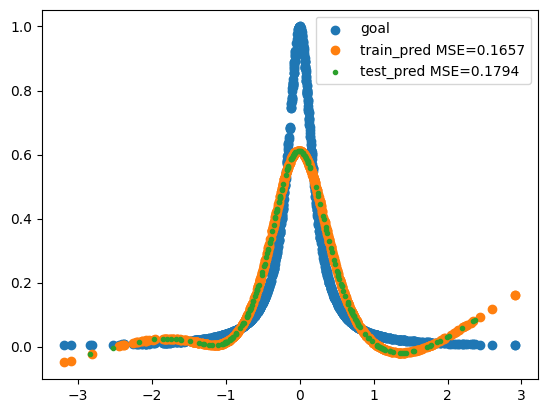

In [34]:
x_test_plot = scalerx.inverse_transform(X_test)[:,0]
y_test_plot = scalery.inverse_transform(test_pred)

x_train_plot = scalerx.inverse_transform(X_train)[:,0]
y_train_plot = scalery.inverse_transform(train_pred)
plt.scatter(xs, ys, label = "goal")
plt.scatter(x_train_plot, y_train_plot, label = f"train_pred MSE={mse_train:.4f}")
plt.scatter(x_test_plot, y_test_plot, marker = ".", label = f"test_pred MSE={mse_test:.4f}")
#plt.scatter(X_train_plot, y_train, label = "train")

plt.legend()
plt.show()